Challenge Data Scientist

Author: Guilherme Garcia Paschoalinoto

Description:
Evaluate the candidate's ability to work with a real-world dataset, perform exploratory data analysis (EDA), preprocess data, build and evaluate a classification model, and interpret the results.

Deliverables:
The submission consists of Python code that is reproducible, in the format most suitable for the candidate (notebooks or scripts). Since the data is public, the submission can be code files, a shared GitHub link, or a shared Kaggle/Colab link. Submit a report or slides to be presented in a new session of up to 30 minutes, plus 15 minutes for discussion.

# Import Libraries

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import PowerTransformer, OrdinalEncoder

# Dataset

The dataset contains information on marketing campaigns from a Portuguese banking institution. The goal is to predict whether a client will subscribe to a term deposit. There are over 40,000 examples with variables and a target.

Dataset URL: https://www.kaggle.com/datasets/abdelazizsami/bank-marketing/data

In [2]:
dataset_path = kagglehub.dataset_download("abdelazizsami/bank-marketing")

csv_path = f"{dataset_path}/bank-full.csv"
df = pd.read_csv(csv_path, sep=';', encoding='latin1')

print('Dataframe length:', df.shape)
df.head()

Dataframe length: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


It is possible to verify that the variables in the dataset have appropriate data types for exploratory data analysis, with numerical columns such as age represented as int64 and categorical columns such as job defined as object. Maintaining correct data types at this stage is essential to ensure that statistical operations and preprocessing procedures are applied consistently, preventing misinterpretation or unnecessary conversions.

In subsequent feature engineering steps, binary variables such as default, housing, loan, and the target variable y will be converted to numeric format (1 and 0), facilitating their use in machine learning models. Furthermore, ordinal categorical attributes such as month will be standardized to numeric values from 1 to 12, reflecting their ordinal nature and allowing algorithms to capture temporal relationships more effectively.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


The analysis with df.describe(include='number') provides an initial understanding of the dataset's characteristics, offering information about the distribution, variability, and central tendencies of the data. From this analysis, it is possible to perform tasks such as:

- Understanding the distribution: Comparing the mean and median helps to identify whether the data is symmetrically distributed or exhibits skewness.

- Outlier identification: Values far above or below the quartiles may indicate atypical observations.

- Data dispersion: The standard deviation shows the variability around the mean, allowing assessment of the consistency and heterogeneity of the variables.

- Preprocessing decisions: Information on minimum, maximum, and quartiles helps guide standardization, normalization, or discretization of variables.

- Missing data verification: The count indicates the number of non-null values, but it is important to consider that missing values may be represented in other ways, such as "unknown", which are not captured by this measure.

For example, for the feature age, the mean is slightly higher than the median, indicating a slightly right-skewed distribution, possibly due to some older clients. The standard deviation suggests that most clients are concentrated between approximately 30 and 51 years old (mean 41 ± 1 standard deviation). Extreme values below 30 or above 50 are less common, as indicated by the column’s minimum and maximum.

In [4]:
df.describe(include='number', percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
10%,29.000000,0.000000,5.000000,58.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
90%,56.000000,3574.000000,28.000000,548.000000,5.000000,185.000000,2.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Unlike the descriptive statistics for numerical data, for categorical data it is possible to observe measures such as diversity, frequency, and class imbalance.

For example, binary categorical variables such as default, housing, loan, and y can be identified with two unique values. The column poutcome contains missing values masked as "unknown" in 81% of the entries, revealing the presence of hidden missing data in the dataset. Additionally, the target variable y is imbalanced, with 88% of the values being "no", indicating that some treatment is required to ensure that metrics such as accuracy remain reliable.

In [5]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


# Exploratory Data Analysis

The exploratory data analysis (EDA) is a crucial step in any data science process, as it helps you truly understand your dataset before modeling. Through EDA, you can explore data distributions, identify outliers or anomalies, detect and handle missing values, visualize relationships between features, and uncover trends or hidden patterns that guide better decisions and more accurate model development.

## Duplicated Values

In [6]:
print('Total of duplicated values:', df[df.duplicated()].shape[0])
df[df.duplicated()].head(1)

Total of duplicated values: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


## Missing Values

In [7]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Although the null value count is zero, missing values masked as the entry "unknown" were identified, as shown in the analysis below. This is a common situation in real-world datasets, where missing information may be represented in various ways other than explicit None or NaN values.

In [8]:
for col in ['job', 'education',
            'contact', 'poutcome']:
    total = len(df)

    empty_count = (df[col].isna().sum() +
                   df[col].apply(lambda x: x == [] if isinstance(x, list) else False).sum() +
                   (df[col] == 'unknown').sum()
                )
    
    percent_empty = empty_count / total * 100

    print(f'{percent_empty:.2f}% of "unknown" values - Feature "{col}"')
    print(df[col].value_counts(dropna=False))
    print('-'*50)


0.64% of "unknown" values - Feature "job"
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
--------------------------------------------------
4.11% of "unknown" values - Feature "education"
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
--------------------------------------------------
28.80% of "unknown" values - Feature "contact"
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
--------------------------------------------------
81.75% of "unknown" values - Feature "poutcome"
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64
--------------------------------------------------


`job:` This feature contains only 0.64% of missing values masked as "unknown". The most appropriate approach in this scenario is to retain it as a valid category representing an unspecified profession, since tree-based models (e.g., decision trees or boosting algorithms) can naturally handle well such cases. Additionally, there may be a meaningful behavioral pattern associated with clients who did not disclose their profession, potentially responding differently to the campaign.

Filling the missing values with the mode could introduce noise or yield limited statistical improvement; however, this approach will be explored next for comparison.

Based on the mode, the most common jobs for each age were identified creating the most_common_job column. However, since some ages have too few records (particularly older ones) for the mode to be statistically reliable, I decided to group ages into 5-year bins to improve stability in the analysis.

In [9]:
job_mode_by_age = df[~df['job'].eq('unknown')].groupby('age')['job'].agg(most_common_job=lambda x: x.mode()[0],
                                                                          sample_count='count')

job_mode_by_age.reset_index().sort_values(by='sample_count', ascending=False).pipe(lambda d: d.T.rename(columns=d.T.iloc[0])[1:])

,32,31,33,34,35,36,30,37,39,38,...,86,85,87,89,88,90,92,93,95,94
most_common_job,management,management,management,management,management,management,management,management,blue-collar,blue-collar,...,retired,retired,retired,retired,retired,retired,retired,retired,retired,retired
sample_count,2084,1990,1964,1926,1887,1801,1754,1689,1480,1462,...,9,5,4,3,2,2,2,2,2,1


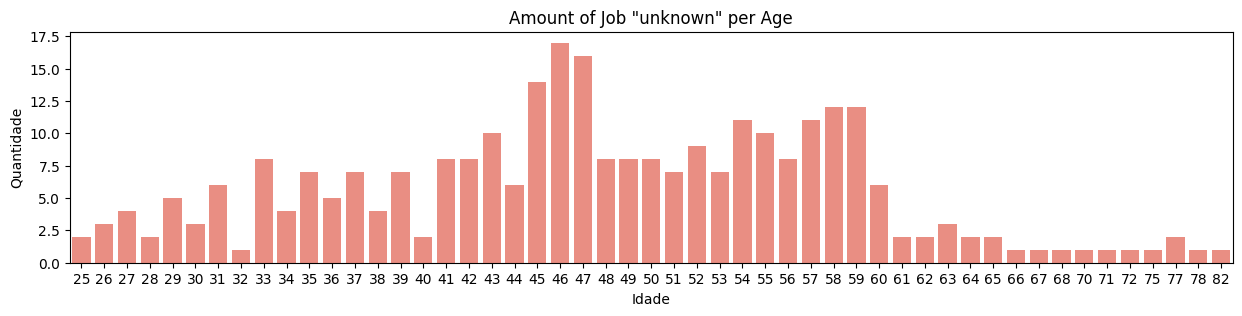

In [10]:
unknown_count_by_age = df[df['job'].eq('unknown')].groupby('age')['job'].count().reset_index(name='unknown_count')

plt.figure(figsize=(15,3))
sns.barplot(x='age', y='unknown_count', data=unknown_count_by_age, color='salmon')
plt.title('Amount of Job "unknown" per Age')
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.show()

In [11]:
df_bins = df.copy()
bins = np.arange(18, df['age'].max() + 5, 5)  # [18, 23, 28, ...]
labels = [f"{b}-{b+4}" for b in bins[:-1]]
df_bins['age_bin'] = pd.cut(df_bins['age'], bins=bins, labels=labels, right=False)
job_mode_by_age_bin = df_bins[~df_bins['job'].eq('unknown')].groupby('age_bin', observed=True)['job'].agg(lambda x: x.mode()[0]).reset_index(name='most_common_job')
job_mode_by_age_bin

,age_bin,most_common_job
0,18-22,student
1,23-27,blue-collar
2,28-32,management
3,33-37,management
4,38-42,blue-collar
5,43-47,blue-collar
6,48-52,blue-collar
7,53-57,management
8,58-62,retired
9,63-67,retired


Although this mode-based approach can help fill missing values, it may also introduce noise. When analyzing the distribution of jobs by age group, some bins (such as ages 33–37) show very close frequencies between jobs like management and blue-collar. In such cases, filling all missing values in that range with the mode (management, in this example) could create an artificial pattern and misrepresent the true job distribution. Therefore, I decided not to modify this feature and to keep the unknown category as is.

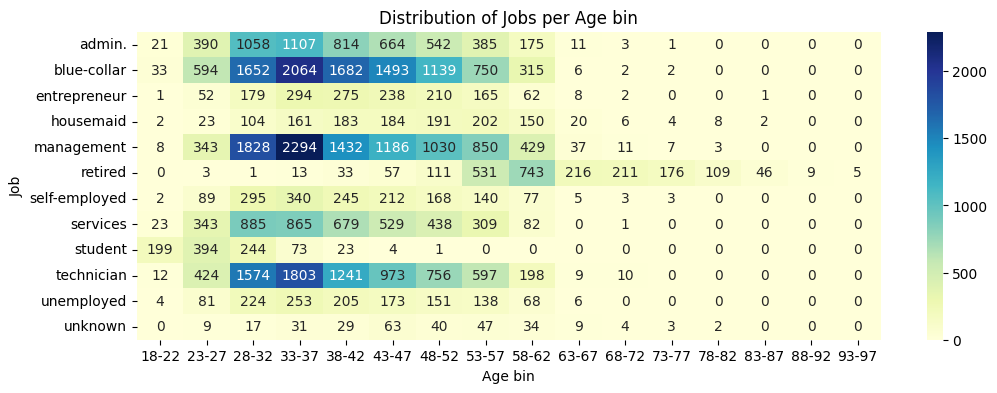

In [12]:
job_age_matrix = df_bins.pivot_table(index='job', columns='age_bin', aggfunc='size', observed=True, fill_value=0)

plt.figure(figsize=(12,4))
sns.heatmap(job_age_matrix, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Distribution of Jobs per Age bin")
plt.xlabel("Age bin")
plt.ylabel("Job")
plt.show()

`education:` Similar to the job feature, the education column has a very low proportion of missing values (4.1%). The potential impacts of handling these missing values are the same: introducing noise, creating artificial patterns, or having limited statistical gain if imputed.

Education is an ordinal categorical variable, with a natural order from primary < secondary < tertiary. Tree-based models or boosting algorithms are particularly suitable for this type of feature, as they can naturally handle categorical variables, respect the ordinal structure, and capture complex, non-linear relationships without requiring explicit encoding. Keeping the "unknown" value does not interfere with the ordinal order of the records and allows the model to account for missing information without introducing artificial assumptions.

Number of "unknown" samples: 1857


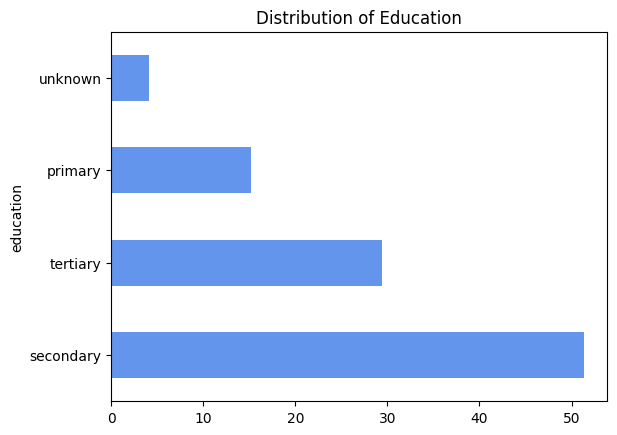

In [13]:
print('Number of "unknown" samples:', df[df['education'].eq('unknown')].shape[0])
round(df['education'].value_counts(normalize=True) * 100, 2).plot(kind = 'barh', title='Distribution of Education', color='cornflowerblue');

From the boxplot of balance by education below, it is possible to observe that there is no clear pattern indicating that individuals with higher education levels consistently have higher average annual balances. However, the few individuals with the highest balances in the dataset belong to the tertiary education group.

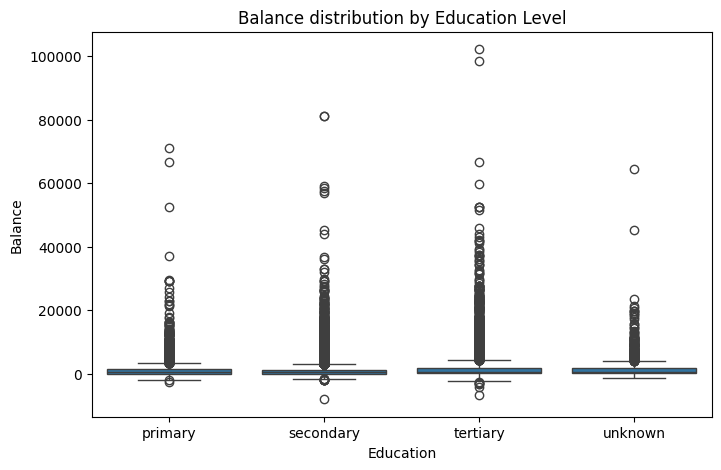

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='education', y='balance', data=df, order=['primary','secondary','tertiary','unknown'])
plt.title('Balance distribution by Education Level')
plt.ylabel('Balance')
plt.xlabel('Education')
plt.show()

From the chart below showing the proportion of default by education level, it can be observed that most contacted clients do not have credit in default. Although the differences across education levels are small, clients with tertiary education show the lowest proportion of defaults. This may suggest a potential relationship between higher education levels and greater financial stability or responsibility, even if the effect is not particularly strong in this dataset.

Since the observed effect is weak, this further supports the decision to preserve the "unknown" category without applying imputation techniques such as the multivariate approach using IterativeImputer or KNNImputer, as these could introduce unnecessary noise rather than improving data quality.

Default proportion by education:
 default          no       yes
education                    
primary    0.981463  0.018537
secondary  0.980260  0.019740
tertiary   0.985114  0.014886
unknown    0.982768  0.017232


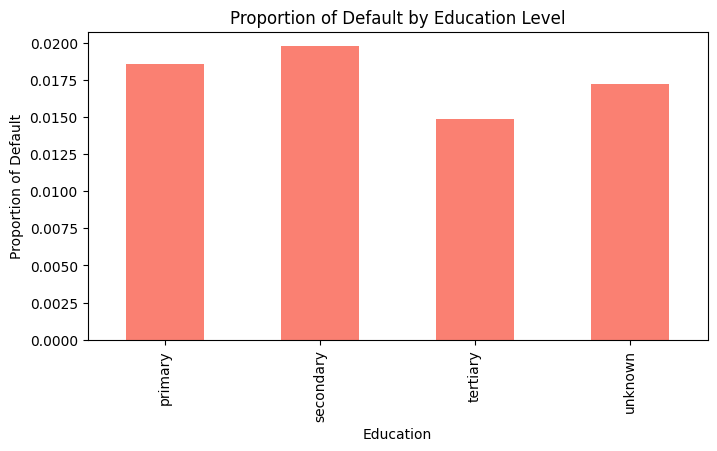

In [15]:
default_rate = pd.crosstab(df['education'], df['default'], normalize='index')
print("Default proportion by education:\n", default_rate)

plt.figure(figsize=(8,4))
default_rate['yes'].plot(kind='bar', color='salmon')
plt.title('Proportion of Default by Education Level')
plt.ylabel('Proportion of Default')
plt.xlabel('Education')
plt.show()

`contact:` The contact feature contains 28% of unknown values, representing missing information. Regardless of contact type, most clients did not subscribe to the term deposit (y = "no"), indicating that the unknown category does not introduce strong bias but reflects unabailable data.

The approach is to keep "unknown" as a valid category and analyse how the models respond to this scenario. If the variable shows low importance in feature importance, it may be disregarded, whereas meaningful importance indicates that the model detected a useful signal.

In [16]:
print('Number of "unknown" samples:', df[df['contact'].eq('unknown')].shape[0])
round(df['contact'].value_counts(normalize=True) * 100, 2)

Number of "unknown" samples: 13020


contact
cellular     64.77
unknown      28.80
telephone     6.43
Name: proportion, dtype: float64

In [17]:
df.groupby('y')['contact'].value_counts()

y    contact  
no   cellular     24916
     unknown      12490
     telephone     2516
yes  cellular      4369
     unknown        530
     telephone      390
Name: count, dtype: int64

`poutcome:` The poutcome feature describes the outcome of the previous marketing campaign. Although 81.75% of its values are recorded as “unknown”, this label likely represents clients who were never contacted before, rather than missing information.

The analysis below shows that clients with a previous “success” outcome have a significantly higher probability of subscribing again, while “failure” and “unknown” categories are mostly associated with non-subscribers.

Therefore, keeping “unknown” as a valid category is the best approach.

In [18]:
print('Number of "unknown" samples:', df[df['poutcome'].eq('unknown')].shape[0])
round(df['poutcome'].value_counts(normalize=True) * 100, 2)

Number of "unknown" samples: 36959


poutcome
unknown    81.75
failure    10.84
other       4.07
success     3.34
Name: proportion, dtype: float64

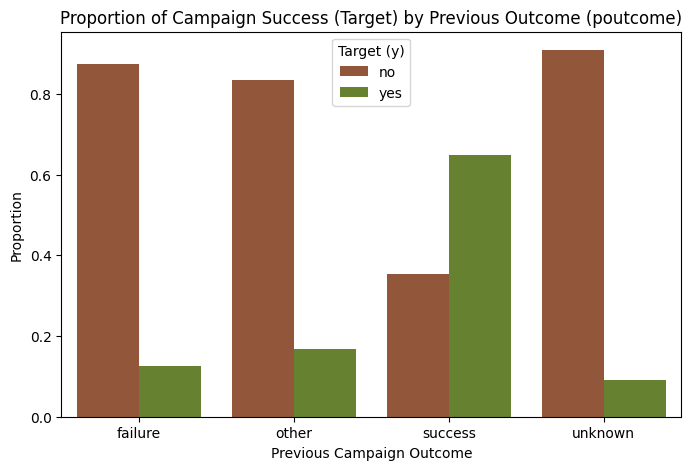

In [19]:
poutcome_y = df.groupby('poutcome')['y'].value_counts(normalize=True).rename('proportion').reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=poutcome_y, x='poutcome', y='proportion', hue='y', palette=['sienna','olivedrab'])
plt.title('Proportion of Campaign Success (Target) by Previous Outcome (poutcome)')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Proportion')
plt.legend(title='Target (y)')
plt.show()

`pdays:` It is observed that 81% of the pdays records have a value of -1, indicating that these clients were never contacted in a previous campaign. Among these, most clients (y = "no") did not subscribe to the term deposit.

Given the high concentration of -1 and its clear semantic meaning, the approach is to replace the pdays feature with a binary variable indicating whether the client was never contacted (pdays = -1) or previously contacted (pdays > 0). This preserves the meaningful information while simplifying the feature for tree-based or boosting models.

In [20]:
print('Number of "-1" samples:', df[df['pdays'].eq(-1)].shape[0])
round(df['pdays'].value_counts(normalize=True) * 100, 2)

Number of "-1" samples: 36954


pdays
-1      81.74
 182     0.37
 92      0.33
 91      0.28
 183     0.28
        ...  
 449     0.00
 452     0.00
 648     0.00
 595     0.00
 530     0.00
Name: proportion, Length: 559, dtype: float64

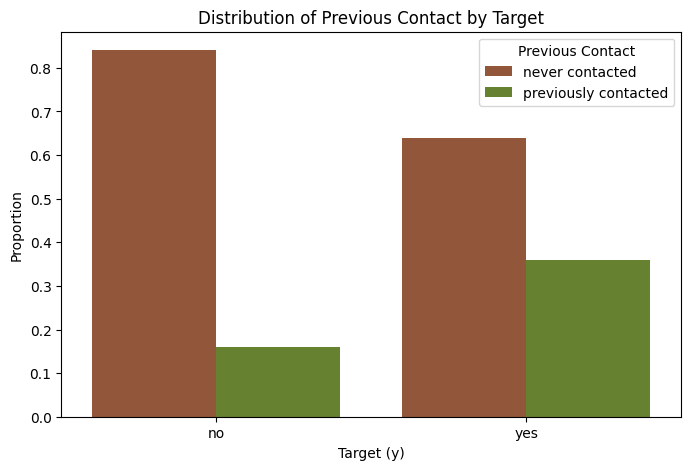

In [21]:
plot_data = df.copy()
plot_data['previous_contact'] = plot_data['pdays'].apply(lambda x: 'never contacted' if x == -1 else 'previously contacted')

plot_data = plot_data.groupby('y')['previous_contact'].value_counts(normalize=True).rename('proportion').reset_index()

plot_data['previous_contact'] = pd.Categorical(plot_data['previous_contact'],
                                               categories=['never contacted','previously contacted'])

plt.figure(figsize=(8,5))
sns.barplot(data=plot_data, x='y', y='proportion', hue='previous_contact',
            palette=['sienna','olivedrab'], hue_order=['never contacted','previously contacted'])
plt.title('Distribution of Previous Contact by Target')
plt.xlabel('Target (y)')
plt.ylabel('Proportion')
plt.legend(title='Previous Contact')
plt.show()

In [22]:
print('Amount of previous == 0:', df[df['previous'].eq(0)].shape[0])

print('Amount of pdays == -1:', df[df['pdays'].eq(-1)].shape[0])

display(df[df['pdays'].eq(-1)].groupby('pdays')['previous'].value_counts().reset_index())

Amount of previous == 0: 36954
Amount of pdays == -1: 36954


,pdays,previous,count
0,-1,0,36954


## Exploring Values

`y (target):` The target variable y is highly imbalanced, with 88.30% of the records labeled as “no” and only 11.70% as “yes”. This imbalance indicates that most clients did not subscribe to the term deposit during the marketing campaign. Such distribution can lead machine learning models to become biased toward the majority class, overestimating negative predictions and underrepresenting potential subscribers.

Therefore, it is essential to apply strategies to handle class imbalance, such as resampling techniques (e.g., SMOTE or random undersampling), adjusting class weights, or focusing on metrics that are robust to imbalance, like Recall, Precision, F1-score, and AUC-ROC to ensure a fair and reliable evaluation of model performance.

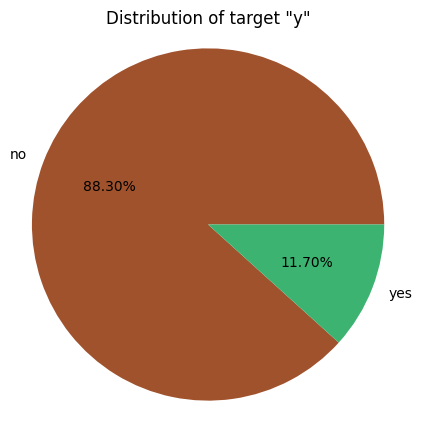

In [23]:
y_counts = df['y'].value_counts()
labels = y_counts.index
sizes = y_counts.values

colors = ['sienna' if label == 'no' else 'mediumseagreen' for label in labels]

plt.figure(figsize=(5, 5))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors
)
plt.title('Distribution of target "y"')
plt.axis('equal')
plt.show()

### Distribution

#### Numerical

- `Age:`: The variable shows right skewness with outliers above 70 years. To limit the influence of extreme values on visualizations and linearity analysis, a winsorization at the 99th percentile will be applied.

- `Balance:`: The distribution is heavily skewed, with values ranging from negative balances up to over 100,000. To handle the skewness and accommodate negative values, a Yeo-Johnson transformation will be applied. This transformation is suitable for variables containing zeros or negative values, reducing skewness while preserving the overall structure of the data.

- `Day:` The variable ranges from 1 to 31 without outliers. It will be kept as a numeric variable without any transformation, since no skewness or extreme values are present, only a multimodal distribution.

- `Duration:` The interquartile range spans from 89 seconds (25th percentile) to 319 seconds (75th percentile) with dispersed values. A logarithmic transformation will be applied to reduce dispersion and better visualize the relationship with the target.

- `Campaign`: Most clients were contacted between 1–5 times, with outliers above the 99th percentile (up to 63 contacts). Winsorization will be applied to limit the effect of extreme campaign counts. After winsorization, the variable can be used numerically or optionally categorized to capture non-linear effects in the relationship with the target.

- `Pdays`: 80% of the data have a value of -1, indicating no previous contact in prior campaigns. A binary variable will be created (0 = not contacted, 1 = contacted).

- `Previous`: Similarly to pdays, 80% of clients have zero previous contacts. A binary variable could be created (0 = not contacted, 1+ = contacted) to capture non-linear effects.

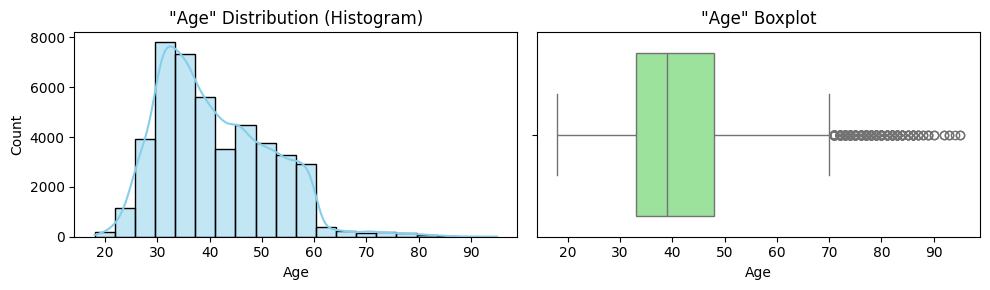

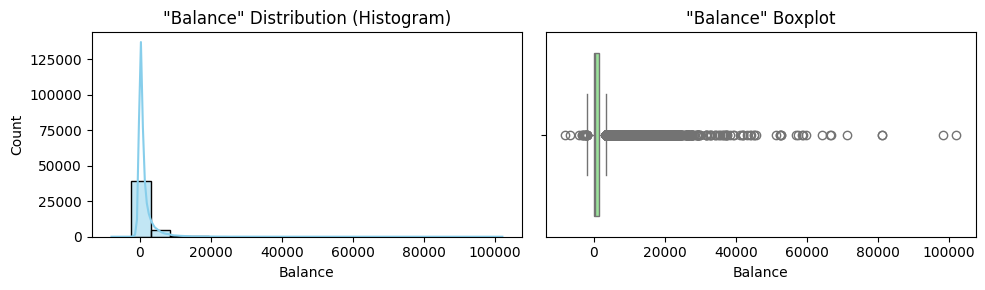

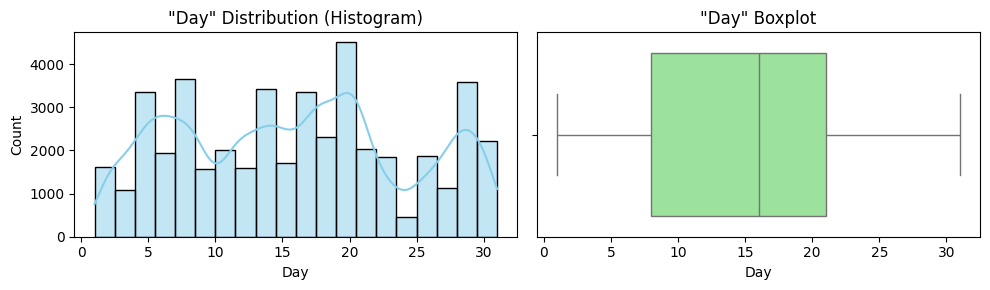

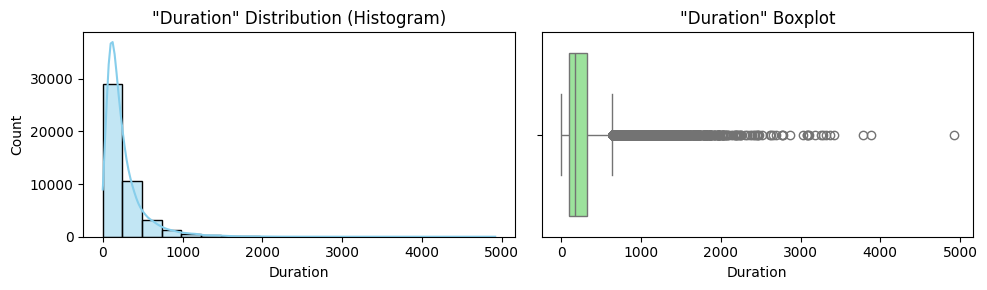

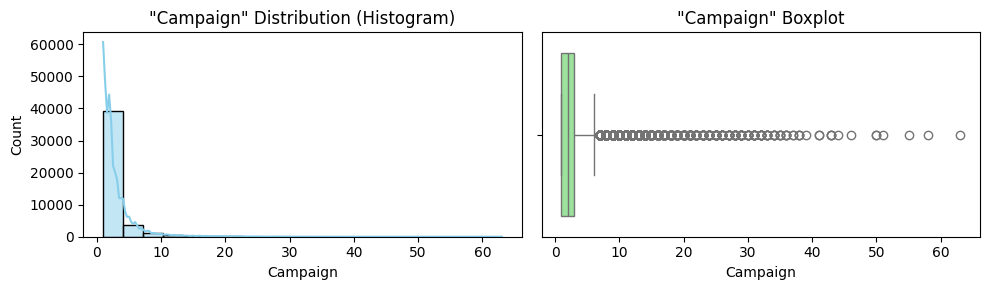

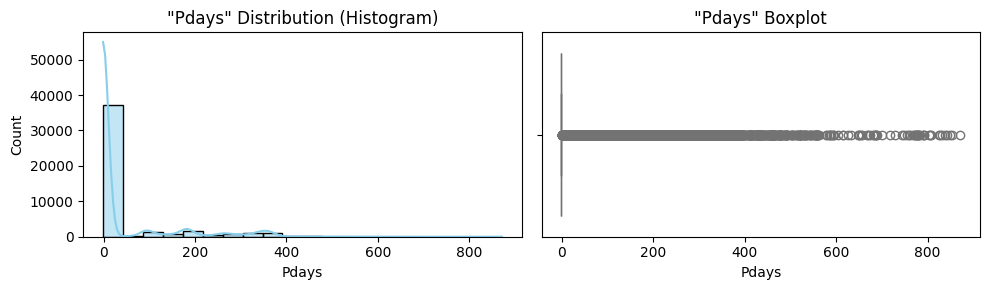

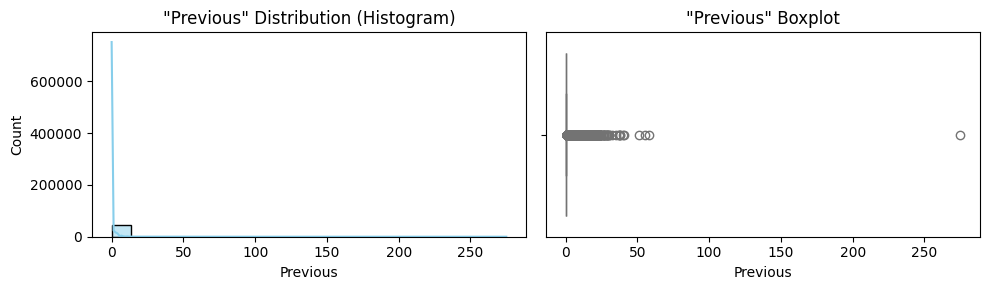

In [24]:
continuous_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

for var in continuous_vars:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
    # Histogram KDE
    sns.histplot(df[var], bins=20, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title(f'"{var.capitalize()}" Distribution (Histogram)')
    axes[0].set_xlabel(var.capitalize())
    axes[0].set_ylabel('Count')
    
    # Boxplot
    sns.boxplot(x=df[var], color='lightgreen', ax=axes[1])
    axes[1].set_title(f'"{var.capitalize()}" Boxplot')
    axes[1].set_xlabel(var.capitalize())
    
    plt.tight_layout()
    plt.show()

After applying the transformations, the numerical features show a more regular and controlled distribution. Although, outliers persist in variables such as duration and balance. This is expected, as Yeo-Johnson and logarithmic transformations compress the distribution and reduce skewness but do not completely eliminate extreme values. These outliers reflect the natural variability of the business, where some clients have unusually high balances or exceptionally long calls.

The boxplots comparing each variable against the target variable y indicate that most features have similar medians between the classes. This suggests that identifying clients who subscribe to the term deposit (“yes”) is not straightforward based on a single feature. Instead, it likely depends on the combination of multiple attributes — for example, it’s not as simple as “younger clients are more likely to subscribe,” but rather how age interacts with other characteristics such as account balance or previous contact history.

However, the feature duration shows a notable difference in medians between classes. Clients who subscribed (“yes”) tend to have significantly longer call durations, implying a strong positive correlation between duration and the likelihood of acceptance. This may also indicate a case of data leakage, as the duration of the call is only known after the contact has occurred. Including this variable in the training data could cause the model to learn an unrealistic rule, such as “if duration > X seconds, predict yes,” leading to artificially inflated performance during training but poor generalization in production. Therefore, this feature should be excluded from the predictive model.

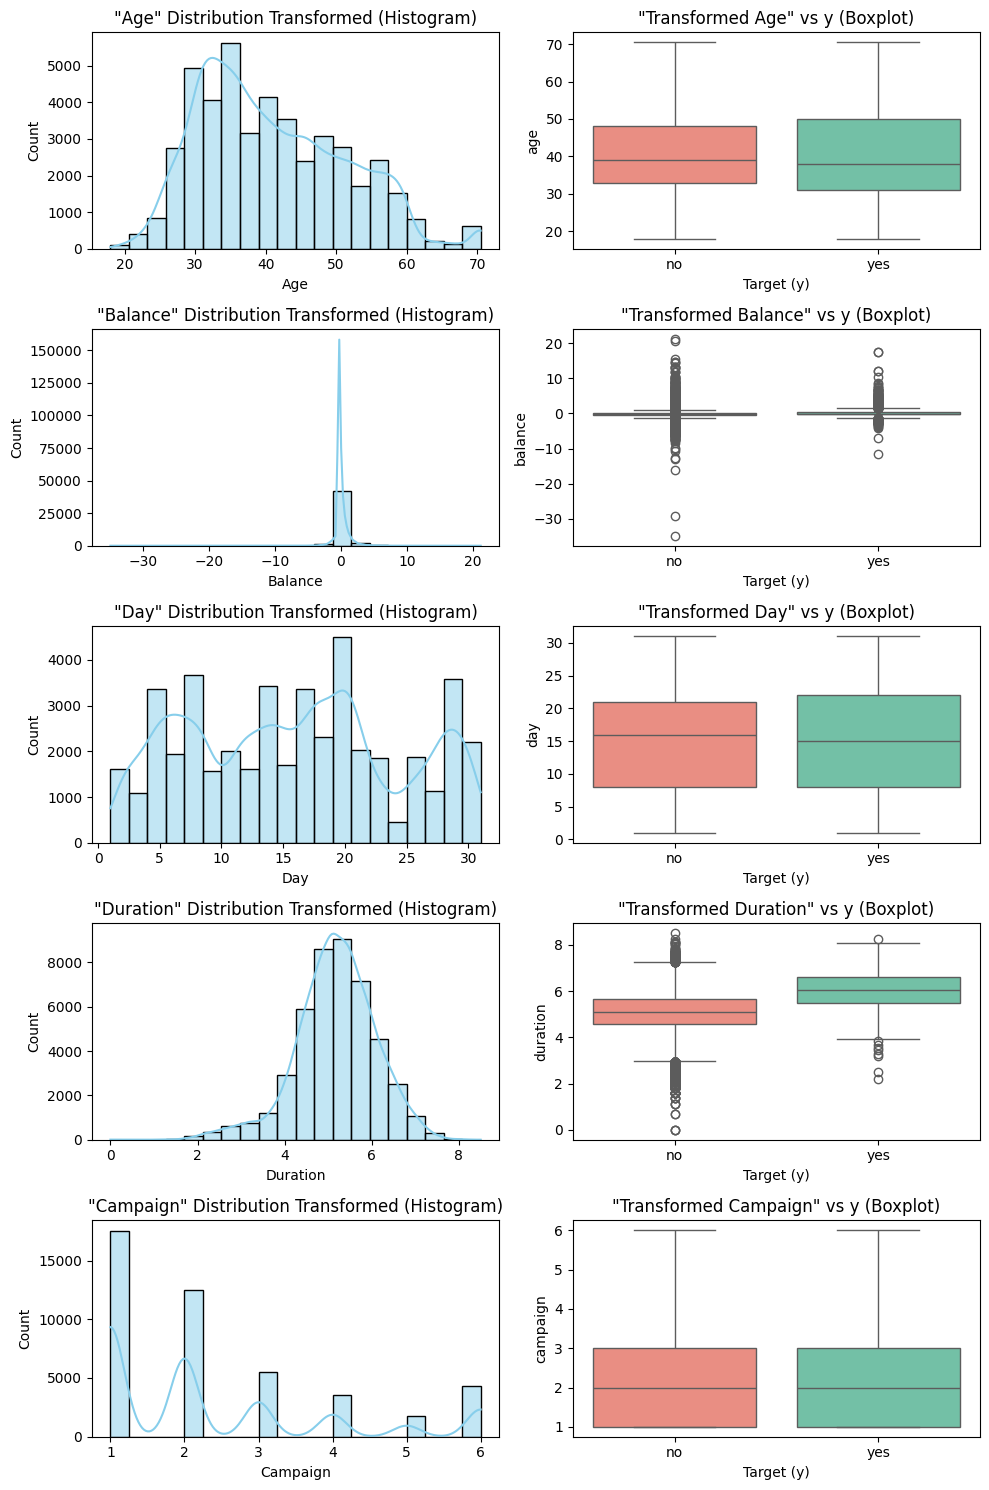

In [25]:
df_prep = df.copy()

# age: winsorization (outliers above 70 years)
winsor_age = Winsorizer(capping_method='iqr', tail='right', fold=1.5, variables=['age'])
df_prep['age'] = winsor_age.fit_transform(df_prep[['age']])

# balance: Yeo-Johnson transformation (negative values and assimetry)
yeo_balance = PowerTransformer(method='yeo-johnson')
df_prep['balance'] = yeo_balance.fit_transform(df_prep[['balance']])

# duration: log transformation (reduce dispersion)
df_prep['duration'] = np.log1p(df_prep['duration'])

# campaign: winsorization (outliers above percentile 99%)
winsor_campaign = Winsorizer(capping_method='iqr', tail='right', fold=1.5, variables=['campaign'])
df_prep['campaign'] = winsor_campaign.fit_transform(df_prep[['campaign']])

# pdays: create binary column
df_prep['contacted_before'] = df_prep['pdays'].apply(lambda x: 'no' if x == -1 else 'yes')

# previous: create binary column
df_prep['previous_contact'] = df_prep['previous'].apply(lambda x: 'no' if x == 0 else 'yes')

df_prep.drop(columns=['pdays', 'previous'], inplace=True)

continuous_vars = ['age', 'balance', 'day', 'duration', 'campaign']

fig, axes = plt.subplots(nrows=len(continuous_vars), ncols=2, figsize=(10, 3 * len(continuous_vars)))

for i, var in enumerate(continuous_vars):
    # Histogram KDE
    sns.histplot(df_prep[var], bins=20, kde=True, color='skyblue', ax=axes[i, 0])
    axes[i, 0].set_title(f'"{var.capitalize()}" Distribution Transformed (Histogram)')
    axes[i, 0].set_xlabel(var.capitalize())
    axes[i, 0].set_ylabel('Count')

    # Boxplot comparison distribution per target
    sns.boxplot(x=df_prep['y'], y=df_prep[var], hue=df_prep['y'], ax=axes[i, 1], palette=['salmon','mediumaquamarine'])
    axes[i, 1].set_title(f'"Transformed {var.capitalize()}" vs y (Boxplot)')
    axes[i, 1].set_xlabel('Target (y)')
    axes[i, 1].set_ylabel(var)

plt.tight_layout()
plt.show()

The pairplot below reveals a strong overlap between the two target classes, suggesting that there is no clear linear decision boundary when observing any pair of variables. This pattern indicates that linear models, such as Logistic Regression, may struggle to capture the underlying relationships in the data. On the other hand, non-linear and ensemble-based models (such as XGBoost, Random Forest, or LightGBM) are better suited for this problem, as they can learn complex, non-linear decision boundaries and are inherently more robust to outliers.

A clearer separation can be seen between duration and age, or duration and day, which may serve as evidence of data leakage. This pattern reflects the predictive dominance of the duration variable, whose influence appears to overshadow what is happening in the other variable. In other words, the model could easily learn a rule based almost entirely on duration, leading to an artificially inflated performance during training and poor generalization in production.

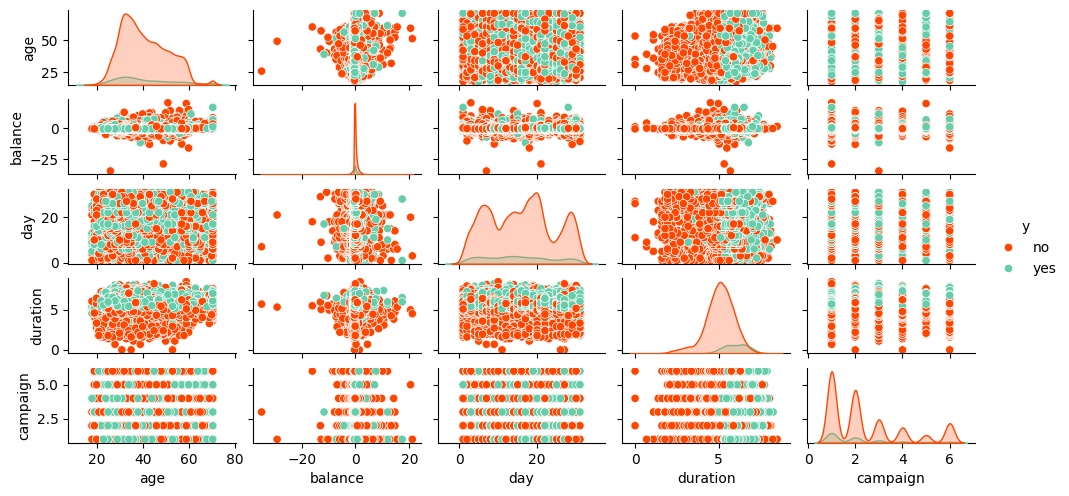

In [26]:
sns.pairplot(df_prep, hue='y', palette=['orangered','mediumaquamarine'], height=1, aspect=2)

#### Categorical

- `Job:` The most common jobs among clients are blue-collar and management, while students represent only 2% of the dataset. This suggests that the bank’s customer base mainly consists of working-class and administrative employees.
- `Marital:` About 70% of the clients are or have been married, which may be related to the average age of 41 years observed in the dataset. This feature could show some correlation with age, indicating potential demographic patterns in the customer base.
- `Education:` As mentioned on the missing values analysis, 4% of the values are labeled as “unknown”. This category will be preserved during encoding to check whether missing educational information carries any predictive influence on the target variable.
- `Default:` The variable shows a strong imbalance, with 98% of clients reporting “no” credit in default. Due to the low variability, this feature is likely to have limited predictive power and may be considered for removal during feature selection.
- `Housing:` This feature indicates whether the client currently holds a housing loan. The classes are almost perfectly balanced (around 50/50).
- `Loan:` About 84% of the values are "no". That could influence the client's decision to subscribe to a term deposit, as individuals with active loans might be more cautious about new investments.
- `Contact:` Most clients (65%) were contacted via cellular and 6% via telephone (likely landline). This suggests a predominant use of mobile communication, reflecting modernization and easier accessibility, while the small share of telephone contacts represents an older and possibly less effective method.
- `Month:` This variable reveals potential seasonality patterns in the marketing campaigns. December represents only 0.5% of the data, possibly reflecting a lower client engagement during the holiday period. May shows the highest activity, likely due to financial planning that occurs after the start of the year.
- `Poutcome, Contacted_before and Previous_contact:` The poutcome variable records the outcome of the previous marketing campaign, with 81% labeled as unknown. This suggests that most clients were not previously contacted, making poutcome strongly correlated with contacted_before and previous. As these features carry redundant information, only poutcome will be kept for modeling since it provides additional detail (success/failure) beyond a simple binary contact indicator.

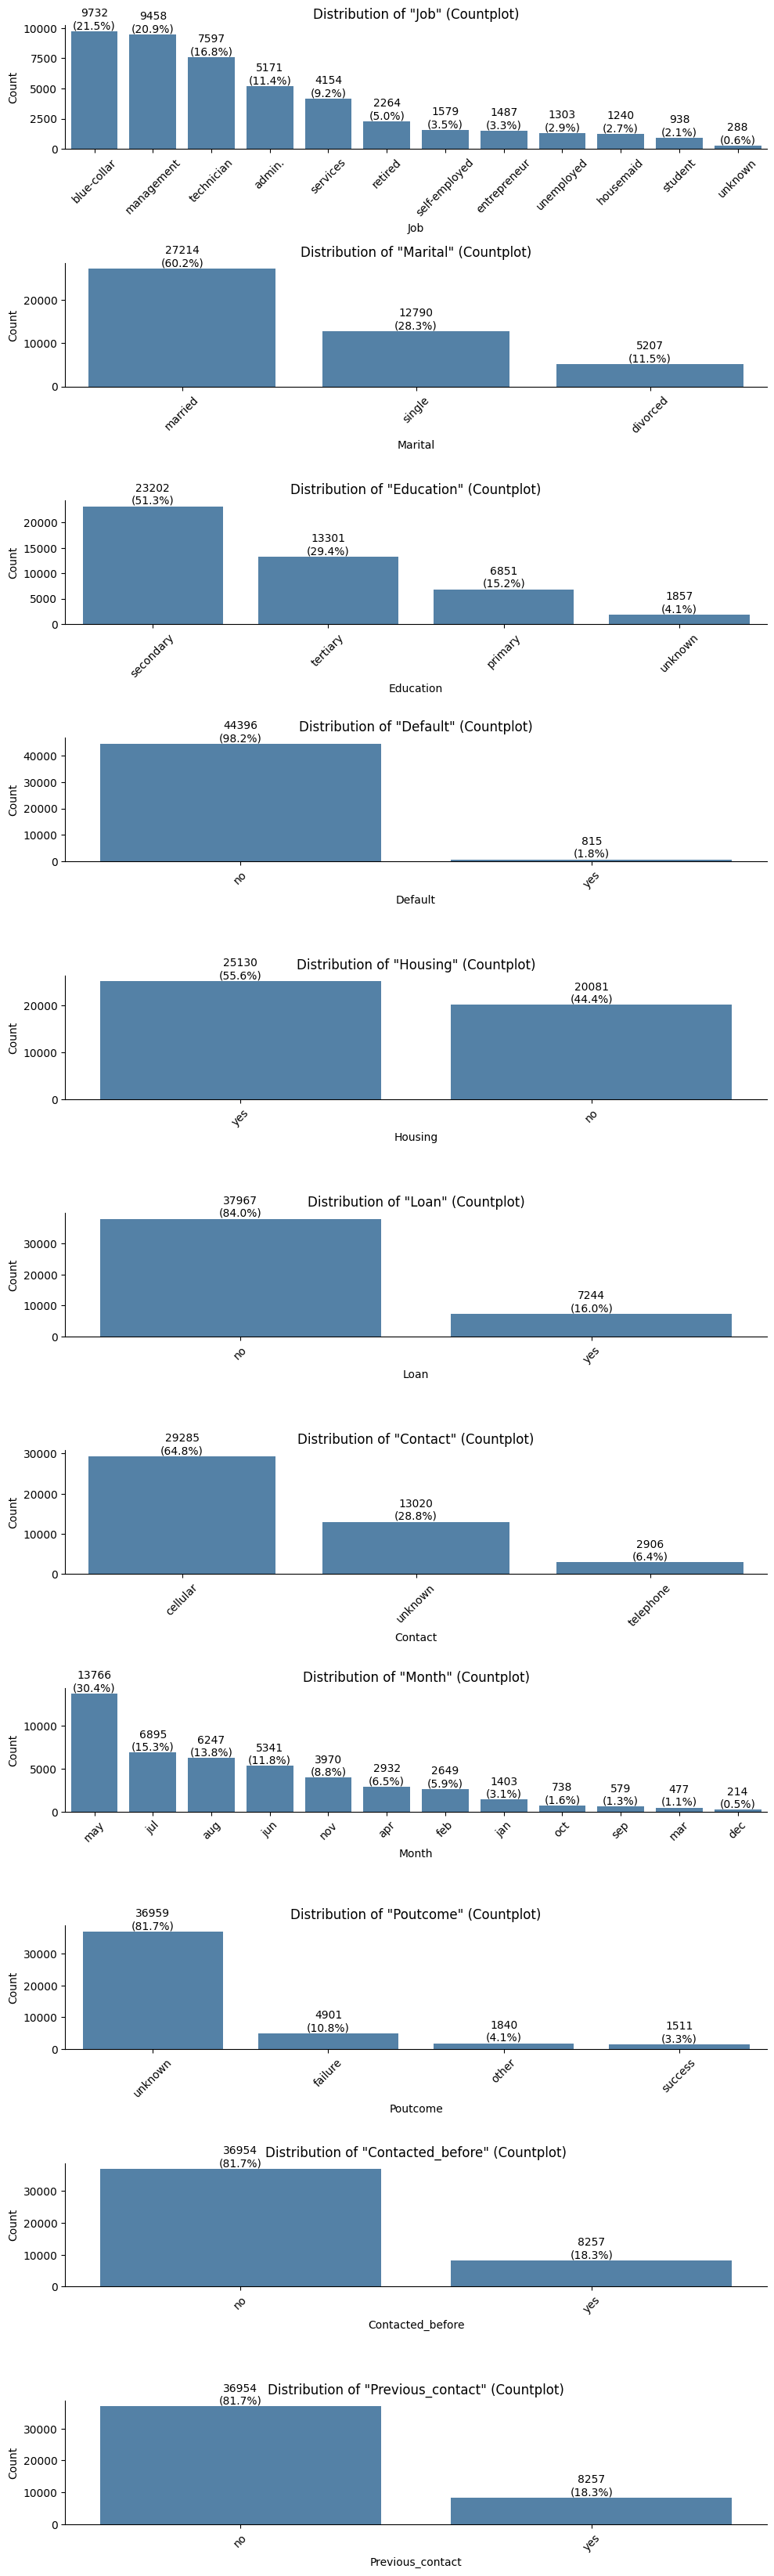

In [27]:
categorical_vars = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month',
                    'poutcome', 'contacted_before', 'previous_contact']

plt.figure(figsize=(10, 3 * len(categorical_vars)))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(len(categorical_vars), 1, i)
    
    order = df_prep[var].value_counts().index
    total = len(df_prep)
    
    sns.countplot(x=var, data=df_prep, order=order, color='steelblue')
    
    # Datalabels
    counts = df_prep[var].value_counts()
    for j, (cat, count) in enumerate(counts.items()):
        plt.text(j, count + 0.5, f'{count}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom')
    
    plt.title(f'Distribution of "{var.capitalize()}" (Countplot)')
    plt.xlabel(var.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    sns.despine()

plt.tight_layout()
plt.show()

`balance vs age vs y`

Across all age groups, the median balance increases with age for both those who accept and those who decline the offer. Customers who accept the offer tend to have slightly better financial health (higher median balances) than those who refuse. This suggests that the term deposit is more appealing to individuals who have some available capital to invest, which makes perfect sense. Customers with lower balances may have other financial priorities.

- For younger clients, having a somewhat higher balance slightly increases the likelihood of acceptance, but the difference is not very large. Other factors may play a more important role in their decision-making.
- For senior clients, having a higher balance appears to be a much stronger indicator of acceptance. The decision of this group seems to be more sensitive to their financial condition.

From a decision-making standpoint, the marketing strategy could be segmented. For senior clients, campaigns could focus on those with balances above a certain threshold, as the likelihood of conversion is higher. Messages for this group could emphasize security and return on capital.

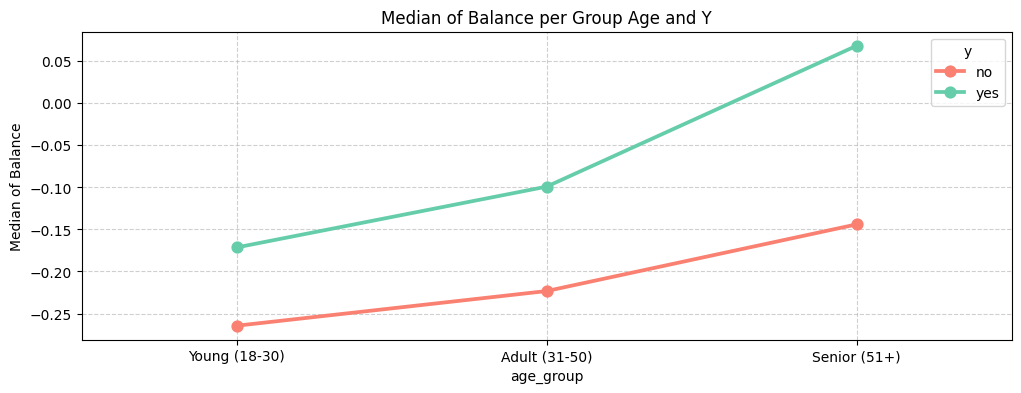

In [28]:
bins = [17, 30, 50, 99] # (18-30, 31-50, 51-99)
labels = ['Young (18-30)', 'Adult (31-50)', 'Senior (51+)']
df_prep['age_group'] = pd.cut(df_prep['age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(12, 4))

sns.pointplot(data=df_prep, x='age_group', y='balance', hue='y', estimator=np.median, errorbar=None, palette=['salmon','mediumaquamarine'])
plt.title('Median of Balance per Group Age and Y')
plt.ylabel('Median of Balance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

`job vs marital vs y`

The graph below reveals two distinct customer personas with exceptionally high conversion rates: divorced retired individuals and single students. This indicates that major life stages—representing moments of financial reorganization or the beginning of financial independence—are powerful drivers for accepting a term deposit offer.

- Retired and divorced clients can be characterized as "Secure Planners." This group often possesses capital from pensions or life event settlements and seeks safe, stable investment vehicles. Their decision-making is primarily driven by a need for capital preservation and predictable, low-risk returns.

- Single students represent a segment of "Aspiring Investors." With fewer financial dependents, their motivation is often to establish good saving habits and take their first step into the world of financial products. For this group, the simplicity and security of a term deposit make it an attractive and accessible option.

From a decision-making standpoint, this allows for the creation of highly targeted marketing campaigns. Campaigns for "Secure Planners" should emphasize security, reliability, and competitive rates for their savings. And, marketing aimed at "Aspiring Investors" should focus on simplicity, the benefits of starting to save early, and ease of access through digital channels.

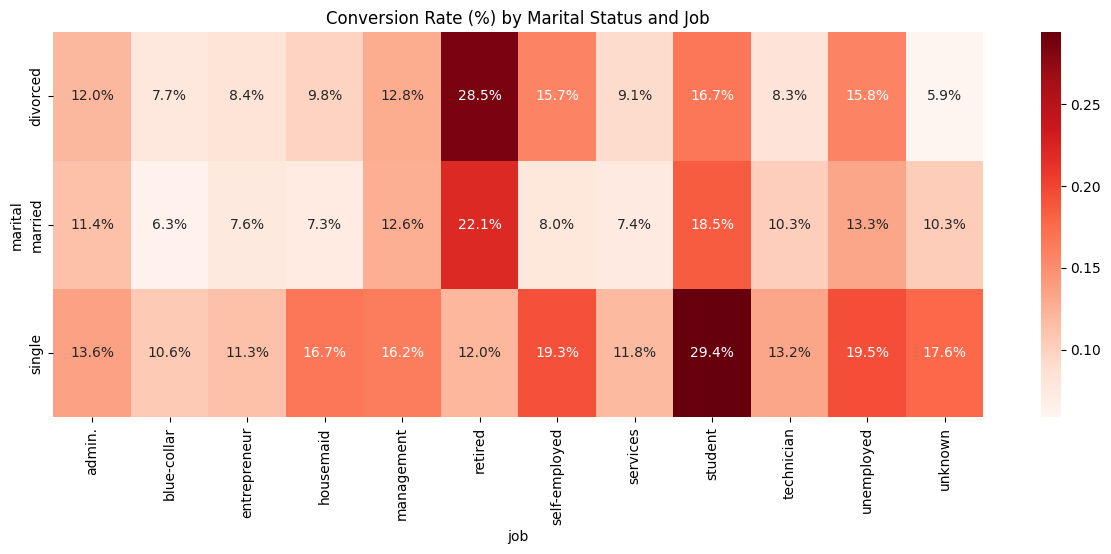

In [29]:
proportions = df_prep.groupby(['marital', 'job'])['y'].value_counts(normalize=True)
proportions_df = proportions.unstack().fillna(0)

conversion_rates = proportions_df[['yes']].reset_index()
conversion_rates.rename(columns={'yes': 'conversion_rate'}, inplace=True)

heatmap_data = conversion_rates.pivot(index='marital', columns='job', values='conversion_rate')

plt.figure(figsize=(15, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1%', cmap='Reds')
plt.title('Conversion Rate (%) by Marital Status and Job')
plt.show()

### Correlation

Although the correlation coefficients between continuous and ordinal/binary categorical variables and the target are low, this indicates that the predictive signal is not driven by direct linear relationships, but rather emerges from complex, non-linear interactions among features.

As previously observed, specific feature combinations—such as retired and divorced clients or single and student clients—exhibit notably higher conversion rates, even though each individual feature shows weak correlation with the target. This reinforces the idea that the model’s predictive power will likely depend on capturing interaction effects, rather than relying solely on individual variable importance.

In [30]:
# Encoding ordinal variable month to correlation analysis
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

oe_month = OrdinalEncoder(categories=[month_order])
month_encoded = oe_month.fit_transform(df_prep[['month']])

df_prep['month_encoded'] = month_encoded

# Encoding ordinal variable education to correlation analysis
education_order = ['primary', 'secondary', 'tertiary', 'unknown']

oe_education = OrdinalEncoder(categories=[education_order])
education_encoded = oe_education.fit_transform(df_prep[['education']])

df_prep['education_encoded'] = education_encoded

ordinal_vars = ['month_encoded', 'education_encoded']

# Encoding binary variables to correlation analysis
binary_cols = [col for col in df_prep.columns if df_prep[col].nunique() == 2]

binary_vars = []

for col in binary_cols:
    if set(df_prep[col].unique()) <= {'yes', 'no'}:
        df_prep[f'{col}_binary'] = df_prep[col].map({'yes': 1, 'no': 0})
        binary_vars.append(f'{col}_binary')

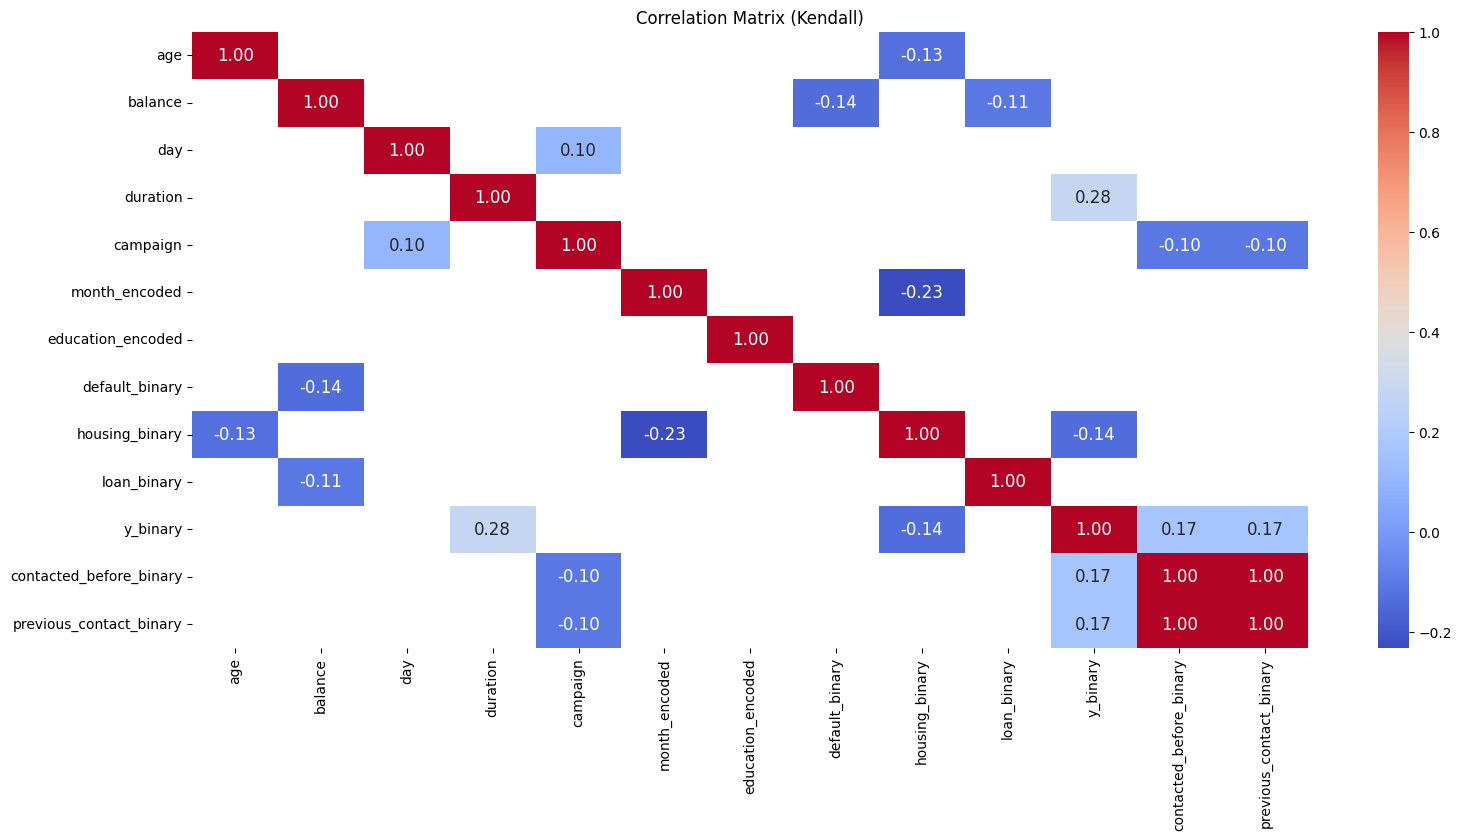

In [31]:
# Correlation Matrix Heatmap
correlation_matrix = df_prep[continuous_vars + ordinal_vars + binary_vars].corr(method='kendall')
correlation_matrix_relevant = correlation_matrix[correlation_matrix.abs() > 0.1]

plt.figure(figsize=(18, 8))
sns.heatmap(correlation_matrix_relevant, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 12})
plt.title('Correlation Matrix (Kendall)')
plt.show()

The next step is the predictive modeling with all the knowledge acquired during this exploratory analysis.